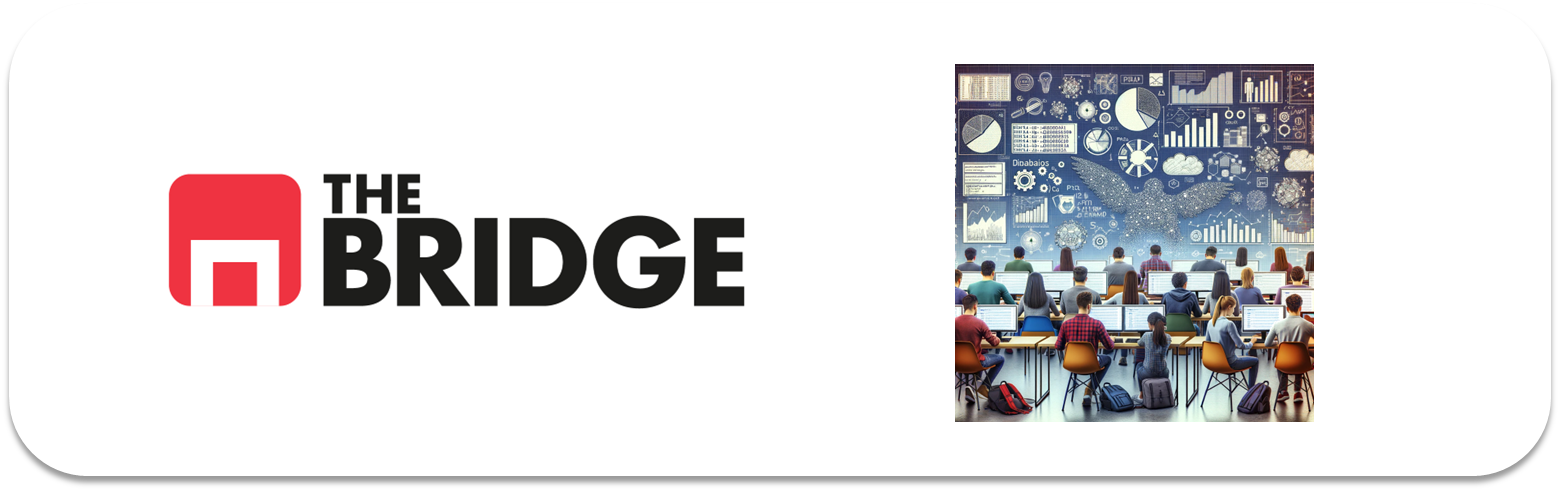

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv("./data/hard_to_find/obligatoria_hard.csv", sep = "|")


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [9]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [10]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT', 'MEDV'],
      dtype='object')

## 2. Análisis de la Variable Target 

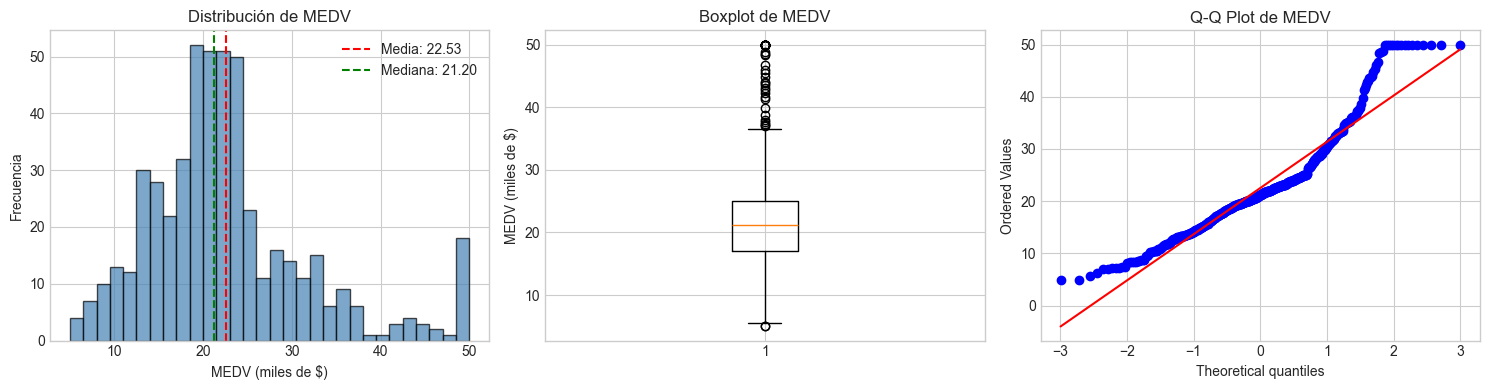


📊 Estadísticas de MEDV:
   Media: 22.53
   Mediana: 21.20
   Desv. Estándar: 9.20
   Mínimo: 5.00
   Máximo: 50.00


In [11]:
# Análisis gráfico de la variable target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma
axes[0].hist(df['MEDV'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('MEDV (miles de $)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de MEDV')
axes[0].axvline(df['MEDV'].mean(), color='red', linestyle='--', label=f'Media: {df["MEDV"].mean():.2f}')
axes[0].axvline(df['MEDV'].median(), color='green', linestyle='--', label=f'Mediana: {df["MEDV"].median():.2f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['MEDV'], vert=True)
axes[1].set_ylabel('MEDV (miles de $)')
axes[1].set_title('Boxplot de MEDV')

# QQ-Plot para normalidad
from scipy import stats
stats.probplot(df['MEDV'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot de MEDV')

plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas de MEDV:")
print(f"   Media: {df['MEDV'].mean():.2f}")
print(f"   Mediana: {df['MEDV'].median():.2f}")
print(f"   Desv. Estándar: {df['MEDV'].std():.2f}")
print(f"   Mínimo: {df['MEDV'].min():.2f}")
print(f"   Máximo: {df['MEDV'].max():.2f}")

In [ ]:
## Mini EDA

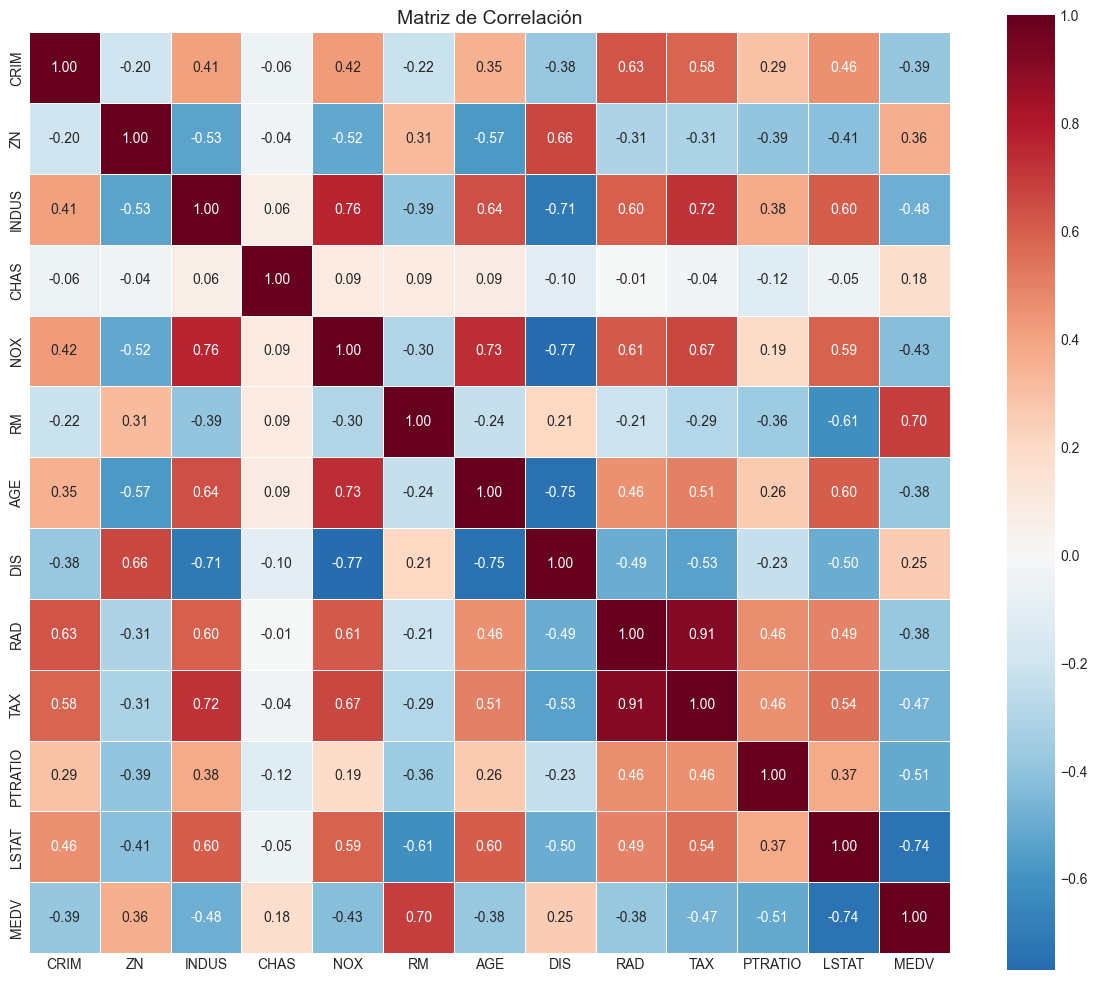


🎯 CORRELACIÓN DE FEATURES CON MEDV (Target)
LSTAT     -0.737663
RM         0.695360
PTRATIO   -0.507787
INDUS     -0.483725
TAX       -0.468536
NOX       -0.427321
CRIM      -0.388305
RAD       -0.381626
AGE       -0.376955
ZN         0.360445
DIS        0.249929
CHAS       0.175260


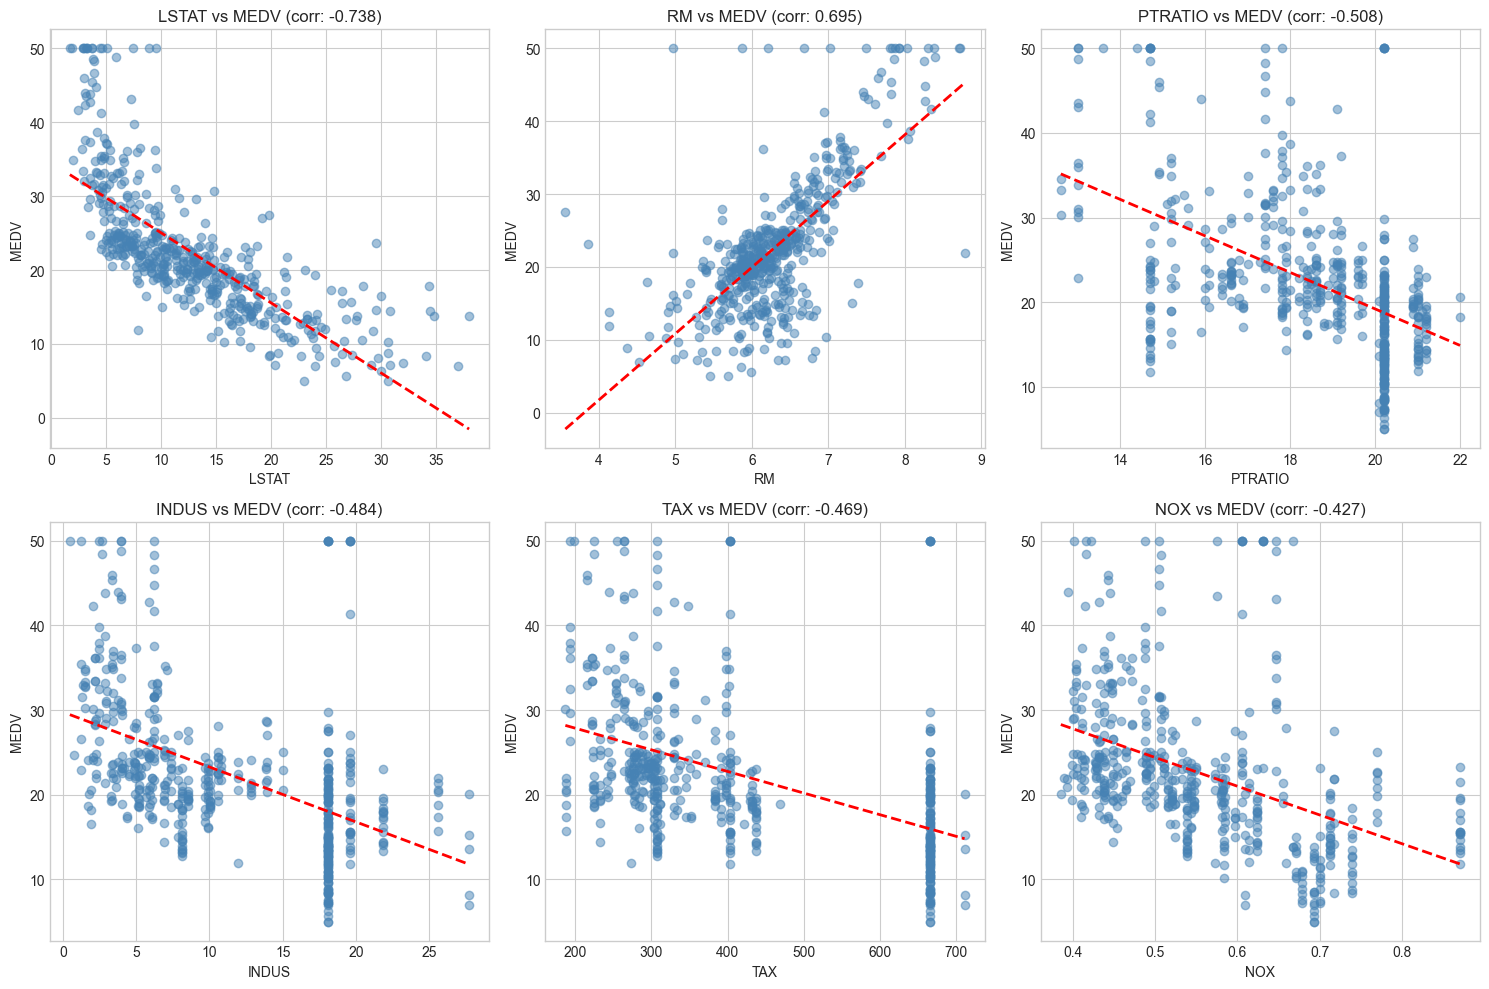

In [12]:
# Matriz de correlación
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.show()

# Correlaciones con el target ordenadas
print("\n🎯 CORRELACIÓN DE FEATURES CON MEDV (Target)")
print("=" * 50)
correlations_with_target = correlation_matrix['MEDV'].drop('MEDV').sort_values(key=abs, ascending=False)
print(correlations_with_target.to_string())

# Visualizar las features más correlacionadas con MEDV
top_features = ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX', 'NOX']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].scatter(df[feature], df['MEDV'], alpha=0.5, color='steelblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('MEDV')
    axes[i].set_title(f'{feature} vs MEDV (corr: {correlation_matrix.loc[feature, "MEDV"]:.3f})')
    
    # Línea de tendencia
    z = np.polyfit(df[feature], df['MEDV'], 1)
    p = np.poly1d(z)
    axes[i].plot(df[feature].sort_values(), p(df[feature].sort_values()), 
                 color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

**Features con correlación ALTA con MEDV:**
- **LSTAT** (-0.74): Correlación negativa fuerte. A mayor % de población de bajo estatus, menor precio.
- **RM** (0.70): Correlación positiva fuerte. Más habitaciones = mayor precio.

**Features con correlación MEDIA:**
- **PTRATIO** (-0.51): Ratio alumno-maestro alto = menor precio.
- **INDUS** (-0.48): Más industria = menor precio.
- **TAX** (-0.47): Más impuestos = menor precio.
- **NOX** (-0.43): Más contaminación = menor precio.

**Decisión:** Usaremos **todas las features** inicialmente y dejaremos que la regularización nos ayude a identificar las más importantes.

In [13]:
# Separar features y target
X = df.drop('MEDV', axis=1)
y = df['MEDV']

print(f"📊 Features (X): {X.shape}")
print(f"🎯 Target (y): {y.shape}")
print(f"\n📋 Features utilizadas: {list(X.columns)}")

📊 Features (X): (506, 12)
🎯 Target (y): (506,)

📋 Features utilizadas: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT']


In [14]:
# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42  # Para reproducibilidad
)

print(f"\n📊 DIVISIÓN DE DATOS")
print("=" * 50)
print(f"✅ Train set: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"✅ Test set: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")


📊 DIVISIÓN DE DATOS
✅ Train set: 404 muestras (79.8%)
✅ Test set: 102 muestras (20.2%)


In [15]:
# Escalado con StandardScaler (media=0, std=1)
scaler = StandardScaler()

# IMPORTANTE: fit solo en train, transform en ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("✅ Features escaladas con StandardScaler")
print("\n📊 Estadísticas de X_train_scaled:")
print(X_train_scaled.describe().loc[['mean', 'std']].round(4))

✅ Features escaladas con StandardScaler

📊 Estadísticas de X_train_scaled:
        CRIM      ZN   INDUS    CHAS     NOX      RM     AGE     DIS     RAD  \
mean -0.0000  0.0000 -0.0000  0.0000 -0.0000 -0.0000 -0.0000  0.0000 -0.0000   
std   1.0012  1.0012  1.0012  1.0012  1.0012  1.0012  1.0012  1.0012  1.0012   

         TAX  PTRATIO   LSTAT  
mean -0.0000   0.0000 -0.0000  
std   1.0012   1.0012  1.0012  


In [16]:
# Crear y entrenar el modelo
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [17]:
# Predicciones
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

In [18]:
# Coeficientes del modelo
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': lr_model.coef_,
    'Abs_Coeficiente': np.abs(lr_model.coef_)
}).sort_values('Abs_Coeficiente', ascending=False)

print(f"\n📊 COEFICIENTES DEL MODELO")
print("=" * 50)
print(f"Intercepto (β₀): {lr_model.intercept_:.4f}")
print(f"\nCoeficientes (βᵢ):")
print(coef_df.to_string(index=False))


📊 COEFICIENTES DEL MODELO
Intercepto (β₀): 22.7965

Coeficientes (βᵢ):
Feature  Coeficiente  Abs_Coeficiente
  LSTAT    -3.819016         3.819016
    DIS    -3.119459         3.119459
     RM     3.004420         3.004420
    NOX    -2.137599         2.137599
    RAD     2.058898         2.058898
PTRATIO    -1.991871         1.991871
    TAX    -1.871317         1.871317
   CRIM    -1.127473         1.127473
   CHAS     0.787152         0.787152
     ZN     0.712109         0.712109
  INDUS     0.173858         0.173858
    AGE    -0.100500         0.100500


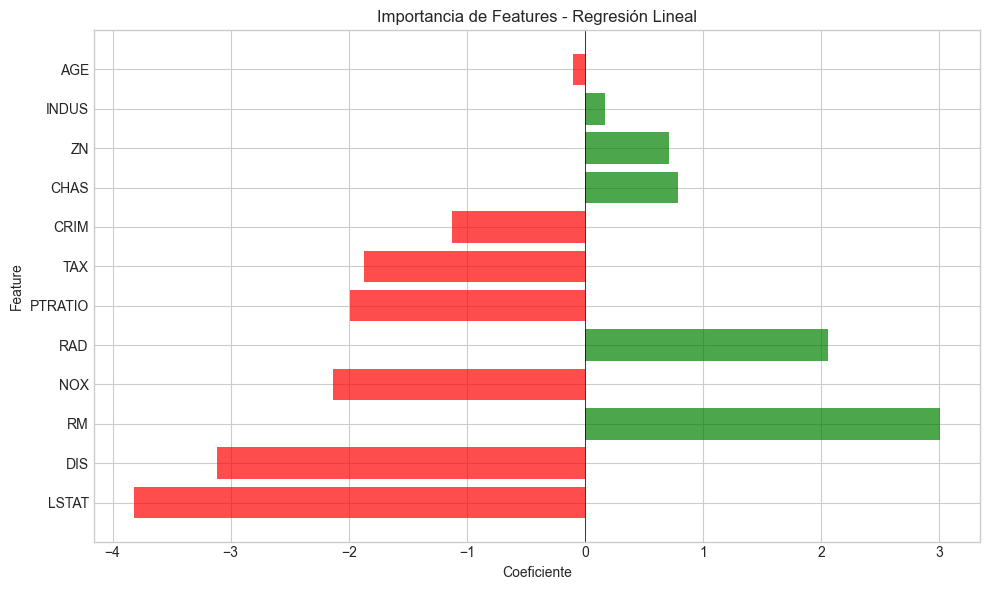


📝 Interpretación:
   🟢 Verde: Coeficiente positivo (aumenta el precio)
   🔴 Rojo: Coeficiente negativo (disminuye el precio)


In [20]:
# Visualización de importancia de features
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coeficiente']]
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors, alpha=0.7)
plt.xlabel('Coeficiente')
plt.ylabel('Feature')
plt.title('Importancia de Features - Regresión Lineal')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\n📝 Interpretación:")
print("   🟢 Verde: Coeficiente positivo (aumenta el precio)")
print("   🔴 Rojo: Coeficiente negativo (disminuye el precio)")

In [22]:
def evaluar_modelo(y_true_train, y_pred_train, y_true_test, y_pred_test, nombre_modelo):
    """Función para evaluar modelos de regresión"""
    
    # Métricas en Train
    mae_train = mean_absolute_error(y_true_train, y_pred_train)
    mse_train = mean_squared_error(y_true_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_true_train, y_pred_train)
    
    # Métricas en Test
    mae_test = mean_absolute_error(y_true_test, y_pred_test)
    mse_test = mean_squared_error(y_true_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_true_test, y_pred_test)
    
    print(f"\n📊 EVALUACIÓN: {nombre_modelo}")
    print("=" * 60)
    print(f"{'Métrica':<15} {'Train':>15} {'Test':>15} {'Diferencia':>15}")
    print("-" * 60)
    print(f"{'MAE':<15} {mae_train:>15.4f} {mae_test:>15.4f} {abs(mae_train-mae_test):>15.4f}")
    print(f"{'MSE':<15} {mse_train:>15.4f} {mse_test:>15.4f} {abs(mse_train-mse_test):>15.4f}")
    print(f"{'RMSE':<15} {rmse_train:>15.4f} {rmse_test:>15.4f} {abs(rmse_train-rmse_test):>15.4f}")
    print(f"{'R²':<15} {r2_train:>15.4f} {r2_test:>15.4f} {abs(r2_train-r2_test):>15.4f}")
    
    return {
        'modelo': nombre_modelo,
        'MAE_train': mae_train, 'MAE_test': mae_test,
        'MSE_train': mse_train, 'MSE_test': mse_test,
        'RMSE_train': rmse_train, 'RMSE_test': rmse_test,
        'R2_train': r2_train, 'R2_test': r2_test
    }

In [23]:
# Evaluar Regresión Lineal
resultados_lr = evaluar_modelo(y_train, y_train_pred_lr, y_test, y_test_pred_lr, "Regresión Lineal")


📊 EVALUACIÓN: Regresión Lineal
Métrica                   Train            Test      Diferencia
------------------------------------------------------------
MAE                      3.4245          3.1114          0.3131
MSE                     22.6043         22.7777          0.1734
RMSE                     4.7544          4.7726          0.0182
R²                       0.7398          0.6894          0.0504


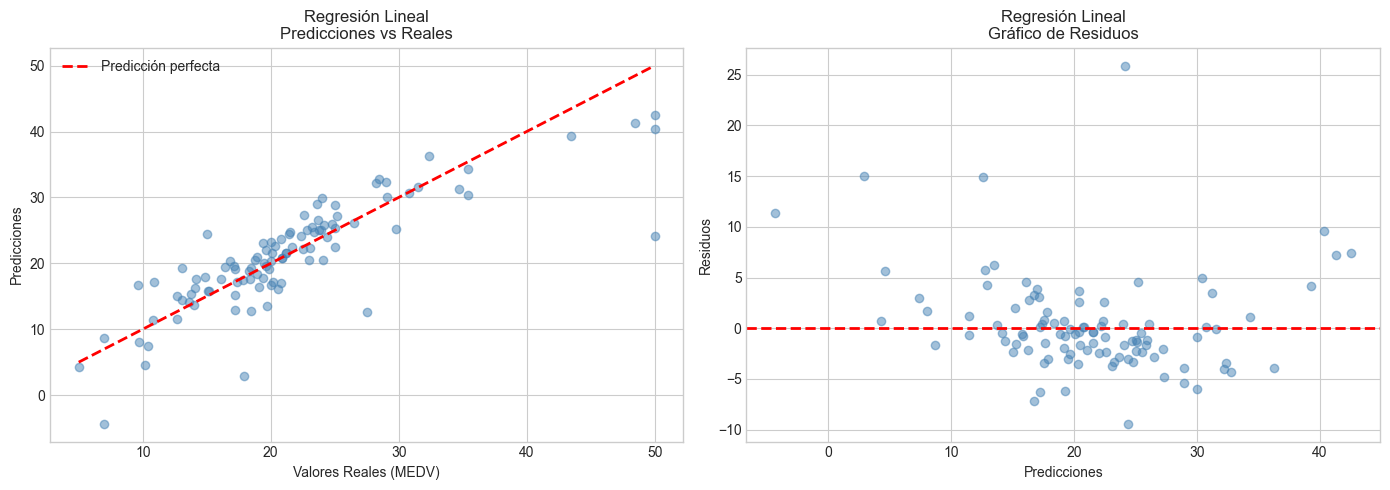

In [24]:
def plot_predicciones(y_true, y_pred, titulo):
    """Visualizar predicciones vs valores reales"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    axes[0].scatter(y_true, y_pred, alpha=0.5, color='steelblue')
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
                 'r--', linewidth=2, label='Predicción perfecta')
    axes[0].set_xlabel('Valores Reales (MEDV)')
    axes[0].set_ylabel('Predicciones')
    axes[0].set_title(f'{titulo}\nPredicciones vs Reales')
    axes[0].legend()
    
    # Residuos
    residuos = y_true - y_pred
    axes[1].scatter(y_pred, residuos, alpha=0.5, color='steelblue')
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicciones')
    axes[1].set_ylabel('Residuos')
    axes[1].set_title(f'{titulo}\nGráfico de Residuos')
    
    plt.tight_layout()
    plt.show()

plot_predicciones(y_test, y_test_pred_lr, "Regresión Lineal")

In [25]:
# Probar diferentes valores de alpha (hiperparámetro de regularización)
alphas_ridge = [0.1, 1.0, 10.0]

resultados_ridge = []

print("\n" + "="*70)
print("🔷 RIDGE REGRESSION (Regularización L2)")
print("="*70)

for alpha in alphas_ridge:
    # Entrenar modelo
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)
    
    # Predicciones
    y_train_pred = ridge_model.predict(X_train_scaled)
    y_test_pred = ridge_model.predict(X_test_scaled)
    
    # Evaluar
    resultado = evaluar_modelo(y_train, y_train_pred, y_test, y_test_pred, f"Ridge (α={alpha})")
    resultado['alpha'] = alpha
    resultado['coeficientes'] = ridge_model.coef_
    resultados_ridge.append(resultado)


🔷 RIDGE REGRESSION (Regularización L2)

📊 EVALUACIÓN: Ridge (α=0.1)
Métrica                   Train            Test      Diferencia
------------------------------------------------------------
MAE                      3.4240          3.1110          0.3131
MSE                     22.6043         22.7811          0.1768
RMSE                     4.7544          4.7730          0.0186
R²                       0.7398          0.6894          0.0505

📊 EVALUACIÓN: Ridge (α=1.0)
Métrica                   Train            Test      Diferencia
------------------------------------------------------------
MAE                      3.4205          3.1074          0.3131
MSE                     22.6056         22.8111          0.2055
RMSE                     4.7545          4.7761          0.0216
R²                       0.7398          0.6889          0.0508

📊 EVALUACIÓN: Ridge (α=10.0)
Métrica                   Train            Test      Diferencia
----------------------------------------------

In [26]:
# Probar diferentes valores de alpha
alphas_lasso = [0.01, 0.1, 1.0]

resultados_lasso = []

print("\n" + "="*70)
print("🔶 LASSO REGRESSION (Regularización L1)")
print("="*70)

for alpha in alphas_lasso:
    # Entrenar modelo
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X_train_scaled, y_train)
    
    # Predicciones
    y_train_pred = lasso_model.predict(X_train_scaled)
    y_test_pred = lasso_model.predict(X_test_scaled)
    
    # Evaluar
    resultado = evaluar_modelo(y_train, y_train_pred, y_test, y_test_pred, f"Lasso (α={alpha})")
    resultado['alpha'] = alpha
    resultado['coeficientes'] = lasso_model.coef_
    resultado['features_no_cero'] = np.sum(lasso_model.coef_ != 0)
    resultados_lasso.append(resultado)
    
    print(f"   Features con coeficiente ≠ 0: {resultado['features_no_cero']}/{len(X.columns)}")


🔶 LASSO REGRESSION (Regularización L1)

📊 EVALUACIÓN: Lasso (α=0.01)
Métrica                   Train            Test      Diferencia
------------------------------------------------------------
MAE                      3.4196          3.1046          0.3150
MSE                     22.6113         22.8535          0.2422
RMSE                     4.7551          4.7805          0.0254
R²                       0.7397          0.6884          0.0514
   Features con coeficiente ≠ 0: 12/12

📊 EVALUACIÓN: Lasso (α=0.1)
Métrica                   Train            Test      Diferencia
------------------------------------------------------------
MAE                      3.3953          3.1677          0.2277
MSE                     23.0894         24.4136          1.3242
RMSE                     4.8051          4.9410          0.1359
R²                       0.7342          0.6671          0.0671
   Features con coeficiente ≠ 0: 10/12

📊 EVALUACIÓN: Lasso (α=1.0)
Métrica                   Train 

In [27]:
# Probar diferentes valores de alpha y l1_ratio
params_elastic = [
    {'alpha': 0.1, 'l1_ratio': 0.5},
    {'alpha': 0.5, 'l1_ratio': 0.5},
    {'alpha': 0.1, 'l1_ratio': 0.9}
]

resultados_elastic = []

print("\n" + "="*70)
print("🔷🔶 ELASTICNET (Regularización L1 + L2)")
print("="*70)

for params in params_elastic:
    # Entrenar modelo
    elastic_model = ElasticNet(alpha=params['alpha'], l1_ratio=params['l1_ratio'], max_iter=10000)
    elastic_model.fit(X_train_scaled, y_train)
    
    # Predicciones
    y_train_pred = elastic_model.predict(X_train_scaled)
    y_test_pred = elastic_model.predict(X_test_scaled)
    
    # Evaluar
    nombre = f"ElasticNet (α={params['alpha']}, l1={params['l1_ratio']})"
    resultado = evaluar_modelo(y_train, y_train_pred, y_test, y_test_pred, nombre)
    resultado['alpha'] = params['alpha']
    resultado['l1_ratio'] = params['l1_ratio']
    resultado['coeficientes'] = elastic_model.coef_
    resultado['features_no_cero'] = np.sum(elastic_model.coef_ != 0)
    resultados_elastic.append(resultado)
    
    print(f"   Features con coeficiente ≠ 0: {resultado['features_no_cero']}/{len(X.columns)}")


🔷🔶 ELASTICNET (Regularización L1 + L2)

📊 EVALUACIÓN: ElasticNet (α=0.1, l1=0.5)
Métrica                   Train            Test      Diferencia
------------------------------------------------------------
MAE                      3.3866          3.1054          0.2812
MSE                     23.1416         23.9868          0.8453
RMSE                     4.8106          4.8976          0.0871
R²                       0.7336          0.6729          0.0607
   Features con coeficiente ≠ 0: 12/12

📊 EVALUACIÓN: ElasticNet (α=0.5, l1=0.5)
Métrica                   Train            Test      Diferencia
------------------------------------------------------------
MAE                      3.5613          3.2076          0.3537
MSE                     26.1828         26.0613          0.1215
RMSE                     5.1169          5.1050          0.0119
R²                       0.6986          0.6446          0.0540
   Features con coeficiente ≠ 0: 9/12

📊 EVALUACIÓN: ElasticNet (α=0.1, l1=